# **Exploring a Public Dataset with Dataprep on Google Cloud Platform**

## **Introduction**

In this assignment, I am exploring the **Chicago Crime dataset** using **Google Cloud Dataprep**, a powerful data preparation tool that allows me to clean, transform, and analyze data through an intuitive visual interface. The dataset includes detailed records of reported crimes in Chicago from 2001 to the present, capturing key information such as date, location, crime type, arrest status, and more.

I am using Dataprep to understand the structure of the dataset, handle missing or inconsistent values, and apply transformations that improve data quality. Through built-in profiling tools and visualizations, I gain insights into crime trends across time, geography, and category.

---

## **Objectives**

- To import and explore the **Chicago Crime dataset** within Google Cloud Dataprep.
- To perform **data cleaning and transformation** tasks such as removing duplicates, handling null values, and formatting fields.
- To use **profiling and visualization features** to detect trends and outliers in the data.
- To write **SQL-like queries** in Dataprep for analyzing crime frequency, types, and distribution.
- To document my workflow and highlight key observations for reporting and presentation.

In [15]:
import pandas as pd

# Load both CSVs
chicago_crime = pd.read_csv("chicago_crime.csv")
extended = pd.read_csv("extended.csv")

# Merge (stack vertically)
merged = pd.concat([chicago_crime, extended], ignore_index=True)

# Preview the result
merged.head()


,Year,Hour,Day,Month,Block,Crime_Type,Description,Location_Description,Arrest,Domestic,District,Community_Area,Latitude,Longitude
0,2023,13,Monday,July,080XX S INGLESIDE AVE,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,False,False,Gresham,Chatham,41.748739,-87.601474
1,2023,23,Thursday,June,048XX W FERDINAND ST,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,SIDEWALK,True,False,Austin,Austin,41.889557,-87.746884
2,2023,21,Friday,July,029XX N CLYBOURN AVE,ASSAULT,SIMPLE,APARTMENT,False,True,Town Hall,North Center,41.934844,-87.681675
3,2023,1,Monday,August,019XX S FAIRFIELD AVE,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,Ogden,South Lawndale,41.854152,-87.694285
4,2023,7,Sunday,June,039XX W POLK ST,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,Harrison,West Garfield Park,41.870740,-87.723749


In [16]:
df_map = merged[['Latitude', 'Longitude', 'Crime_Type']].dropna().head(500)

In [17]:
import folium

# Center the map on Chicago
map_center = [41.8781, -87.6298]  # Chicago's coordinates
crime_map = folium.Map(location=map_center, zoom_start=11)

# Add points
for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        popup=row['Crime_Type'],
        fill=True,
        color='red',
        fill_opacity=0.6
    ).add_to(crime_map)

# Display it
crime_map


In [18]:
from folium.plugins import HeatMap
import folium

# Create a new map centered on Chicago
heat_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Prepare the data for the heat map
heat_data = df_map[['Latitude', 'Longitude']].values.tolist()

# Add heatmap with custom gradient
HeatMap(
    heat_data,
    radius=8,
    blur=15,
    gradient={0.2: 'green', 0.5: 'yellow', 0.8: 'red'}
).add_to(heat_map)

heat_map


AttributeError: 'float' object has no attribute 'split'

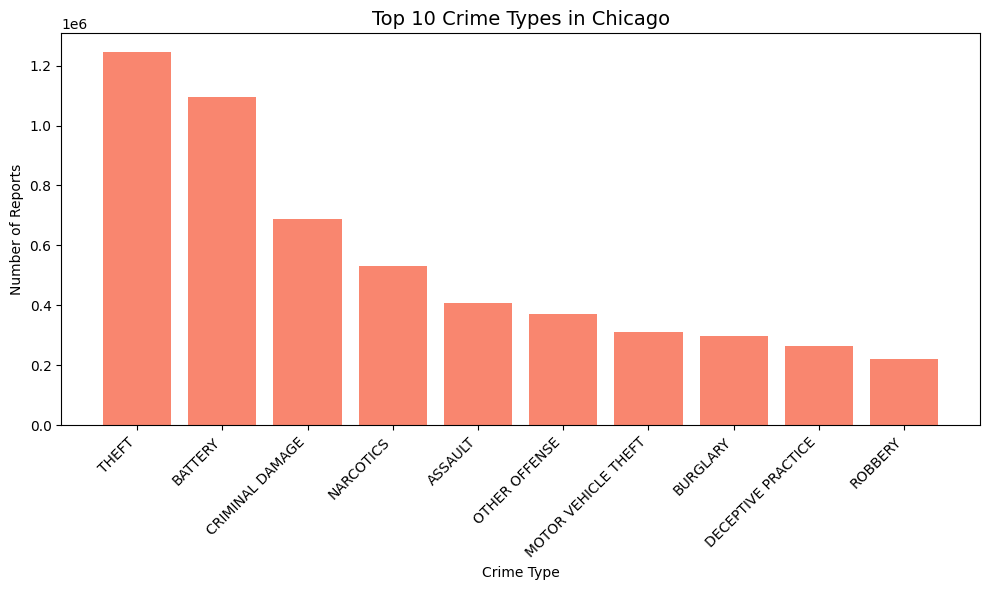

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
merged = pd.read_csv("chicago_crime.csv")

# Get top 10 crime types
top_crimes = merged['Crime_Type'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_crimes.index, top_crimes.values, color='#f9866f')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Crime Types in Chicago", fontsize=14)
plt.xlabel("Crime Type")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.show()
